In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_decisionTree.csv")
df = pd.DataFrame(data)

In [38]:
df

,feature,scores,ci
0,E2F1..nuc.median. & cycA..nuc.median.,-0.006262,0.024782
1,E2F1..nuc.median. & cycD1..nuc.median.,0.002989,0.024782
2,E2F1..nuc.median. & p21..nuc.median.,0.008364,0.024782
3,E2F1..nuc.median. & Int_Intg_DNA_nuc,0.014850,0.024782
4,E2F1..nuc.median. & Skp2..nuc.median.,-0.002867,0.024782
...,...,...,...
34186,CDK2_cyto_over_nuc & Local.cell.density,-0.005729,0.014275
34187,CDK2_cyto_over_nuc & ratio,-0.011693,0.014275
34188,STAT3..phospho.total.nuc. & Local.cell.density,0.001149,0.016657
34189,STAT3..phospho.total.nuc. & ratio,-0.002814,0.016657


In [40]:
import re

def rename_feature(name):
    # Pattern for matching each feature of the form Protein..loc.metric.
    pattern = r"(\w+)\.\.(nuc|cyto)\.\w+\."

    def repl(match):
        protein, location = match.groups()
        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
        return f"{protein} ({location_full})"

    # Apply substitution to all matching parts of the string
    return re.sub(pattern, repl, name)

#def rename_feature(name):
#    match = re.match(r"(\w+)\.\.(nuc|cyto)\.\w+\.", name)
#    if match:
#        protein, location = match.groups()
#        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
#       return f"{protein} ({location_full})"
#    return name  # leave unchanged if it doesn't match the pattern

# Apply renaming
renamed_features = [rename_feature(col) for col in df["feature"]]

In [43]:
df["feature"] = renamed_features
top_20 = df.nlargest(10, "scores")
#top_20.replace('Nuc.area', 'Area (nucleus)', inplace=True)
#top_20.replace('Int_Intg_DNA_nuc', 'DNA (nucleus)', inplace=True)

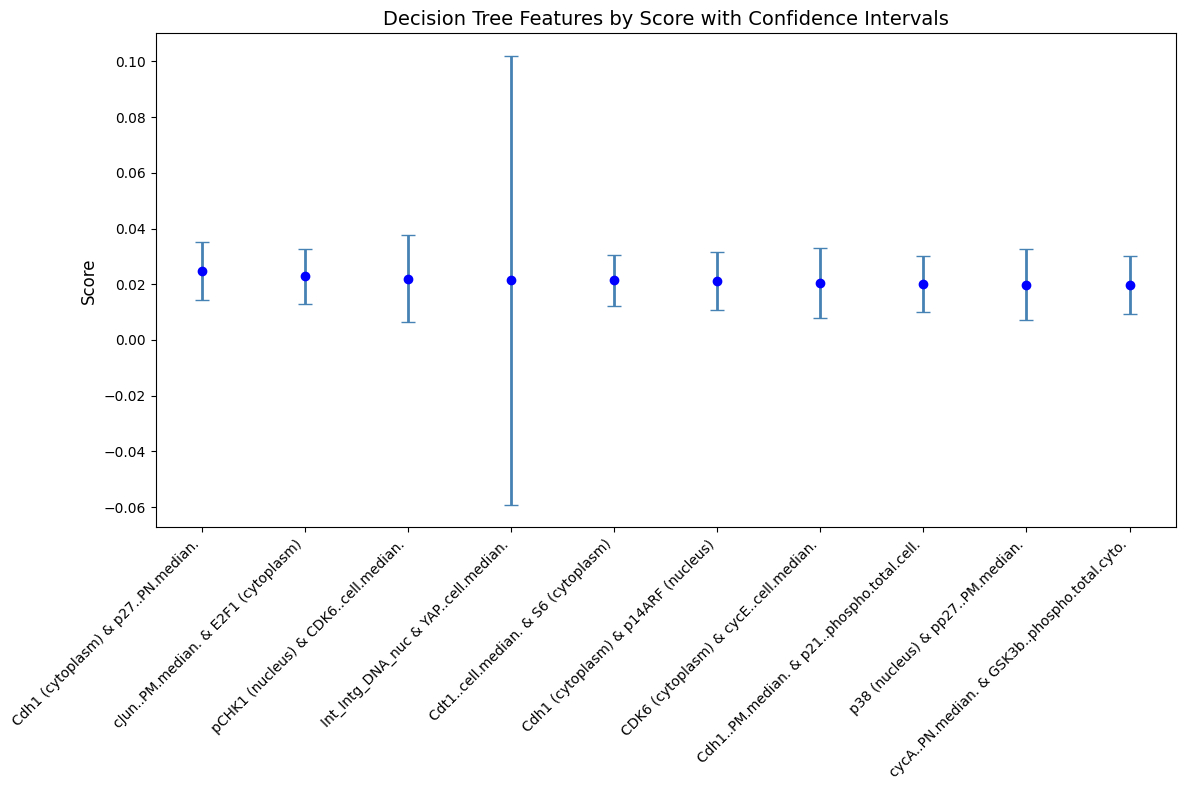

In [54]:
# Plot
plt.figure(figsize=(12, 8))
plt.errorbar(
    top_20["feature"],
    top_20["scores"],
    yerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=45, fontsize=10, ha = "right")  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.title("Decision Tree Features by Score with Confidence Intervals", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

In [65]:
xgb_data = pd.read_csv("/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_xgb.csv")
xgb_df = pd.DataFrame(xgb_data)

In [66]:
import re

def rename_feature(name):
    # Pattern for matching each feature of the form Protein..loc.metric.
    pattern = r"(\w+)\.\.(nuc|cyto)\.\w+\."

    def repl(match):
        protein, location = match.groups()
        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
        return f"{protein} ({location_full})"

    # Apply substitution to all matching parts of the string
    return re.sub(pattern, repl, name)

#def rename_feature(name):
#    match = re.match(r"(\w+)\.\.(nuc|cyto)\.\w+\.", name)
#    if match:
#        protein, location = match.groups()
#        location_full = 'nucleus' if location == 'nuc' else 'cytoplasm'
#       return f"{protein} ({location_full})"
#    return name  # leave unchanged if it doesn't match the pattern

# Apply renaming
renamed_features = [rename_feature(col) for col in xgb_df["feature"]]

In [67]:
xgb_df["feature"] = renamed_features
top_20_xgb = xgb_df.nlargest(10, "scores")

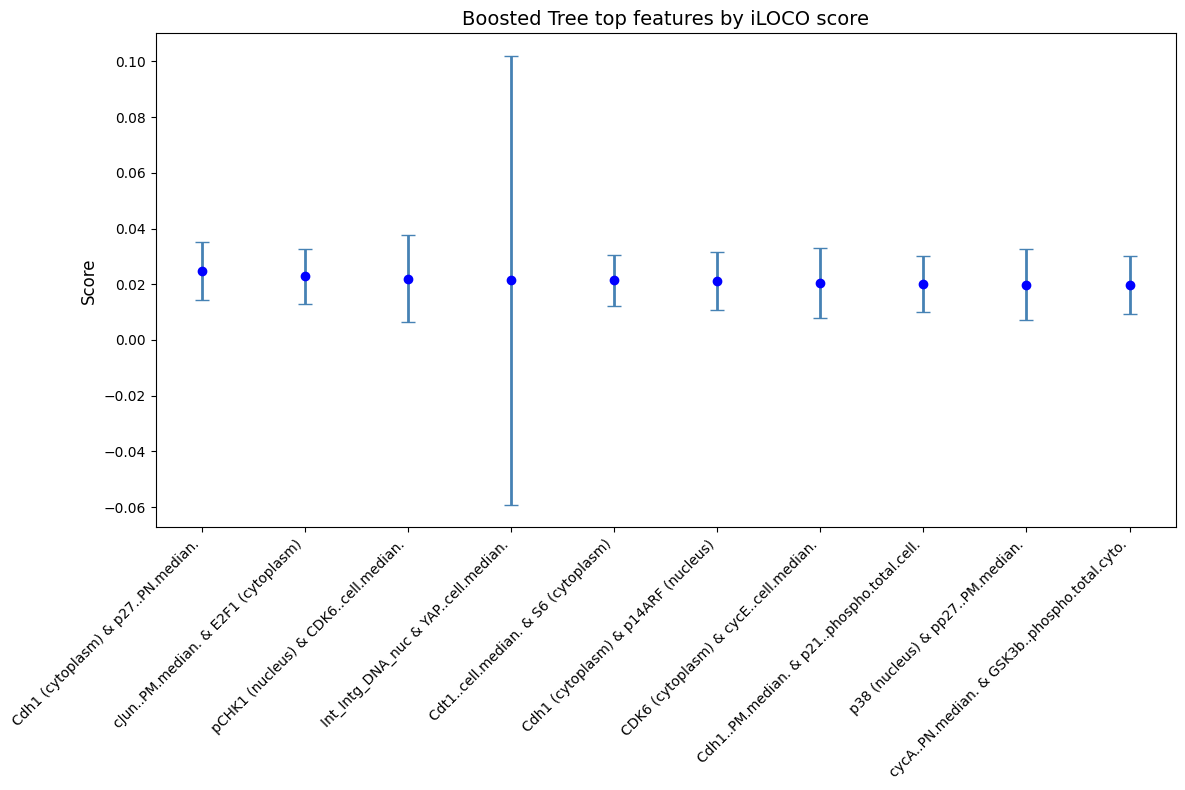

In [68]:
# Plot
plt.figure(figsize=(12, 8))
plt.errorbar(
    top_20_xgb["feature"],
    top_20_xgb["scores"],
    yerr=top_20_xgb["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=45, fontsize=10, ha = "right")  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.title("Boosted Tree top features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()